# 🚀 Practice Day 12

**📅 Date:** 2026-09-23  
**📁 Category:** Phase 3 · 엔드투엔드 미니 파이프라인 (Round 1/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Combine SQL and Pandas in the same workflow instead of picking one (SQL과 Pandas를 하나만 쓰지 않고 같은 워크플로우 안에서 함께 사용)
- Clean a messy real-world-style column (mixed units, missing values) before analyzing it (분석 전에 지저분한 컬럼(단위 혼재, 결측치)부터 정제)
- Combine two tables, two tools, and everything learned so far into one end-to-end mini pipeline (테이블 2개, 도구 2개, 지금까지 배운 것 전부를 하나의 미니 파이프라인으로 연결)

---
# 📂 Dataset

**Dataset Name:** Logistics / Delivery Data (물류·배송 데이터)

**Source:** Synthetically generated for practice, fixed random seed (연습용으로 코드에서 직접 생성, seed 고정)

**Description:** Two related tables. `drivers_df` (14 drivers: vehicle type, NYC neighborhood) and `deliveries_df` (280 delivery records: distance, weight, status). `weight_kg` is deliberately messy — mixed formats ("12.5", "12.5kg", "12.5 kg") plus 12 missing values — so it needs cleaning before it's usable.
(테이블 2개입니다. drivers_df(기사 14명: 차종·뉴욕 동네), deliveries_df(배송 기록 280건: 거리·무게·상태). weight_kg는 일부러 지저분하게 만들었습니다 — "12.5", "12.5kg", "12.5 kg" 등 형식이 섞여 있고 결측치 12건도 포함되어 있어서, 사용하기 전에 정제가 필요합니다.)

## Dataset Preview

In [139]:
# Dataset Preview
import pandas as pd
import numpy as np
from IPython.display import display

np.random.seed(42)

# --- drivers_df ---
n_drivers = 14
last_names = ['Smith', 'Johnson', 'Williams', 'Brown', 'Jones', 'Garcia', 'Miller', 'Davis', 'Wilson', 'Taylor']
first_names = ['James', 'Emma', 'Liam', 'Olivia', 'Noah', 'Ava', 'Ethan', 'Sophia', 'Mason', 'Mia',
               'Lucas', 'Amelia', 'Henry', 'Harper']
driver_names = []
for _ in range(n_drivers):
    last = np.random.choice(last_names)    # same draw order as the original data, so the rest of the data stays the same
    first = np.random.choice(first_names)
    driver_names.append(f'{first} {last}')
vehicle_types = np.random.choice(['Motorcycle', 'Van', 'Truck'], size=n_drivers, p=[0.45, 0.35, 0.20])
regions_list = ['SoHo', 'Williamsburg', 'Midtown', 'Chelsea', 'Astoria']
driver_regions = np.random.choice(regions_list, size=n_drivers, p=[0.30, 0.28, 0.16, 0.14, 0.12])

drivers_df = pd.DataFrame({
    'driver_id': [f'DRV-{i+1:02d}' for i in range(n_drivers)],
    'driver_name': driver_names,
    'vehicle_type': vehicle_types,
    'region': driver_regions,
})

# --- deliveries_df ---
n_deliveries = 280
driver_popularity = np.random.dirichlet(np.ones(n_drivers) * 1.5)
chosen_drivers = np.random.choice(drivers_df['driver_id'], size=n_deliveries, p=driver_popularity)
driver_vehicle_map = dict(zip(drivers_df['driver_id'], drivers_df['vehicle_type']))
vehicle_of_delivery = [driver_vehicle_map[d] for d in chosen_drivers]

distance_km = np.round(np.random.uniform(1, 25, n_deliveries), 1)

# weight scales with the driver's vehicle type (bikes carry less than trucks)
weight_base = {'Motorcycle': 3, 'Van': 15, 'Truck': 80}
weight_kg_numeric = np.array([
    max(0.5, np.random.normal(weight_base[v], weight_base[v] * 0.35)) for v in vehicle_of_delivery
])
weight_kg_numeric = np.round(weight_kg_numeric, 1)

delivery_status = np.random.choice(['Delivered', 'Delayed', 'Failed'], size=n_deliveries, p=[0.80, 0.12, 0.08])
delivery_date = pd.to_datetime(np.random.choice(pd.date_range('2026-04-01', '2026-06-30', freq='D'), size=n_deliveries))

deliveries_df = pd.DataFrame({
    'delivery_id': [f'DEL-{i+1:05d}' for i in range(n_deliveries)],
    'driver_id': chosen_drivers,
    'delivery_date': delivery_date,
    'distance_km': distance_km,
    'weight_kg': weight_kg_numeric,
    'delivery_status': delivery_status,
})

# inject messiness into weight_kg: mixed string formats + missing values
def messy_weight(w):
    r = np.random.random()
    if r < 0.30:
        return f'{w}kg'
    elif r < 0.45:
        return f'{w} kg'
    return str(w)

deliveries_df['weight_kg'] = deliveries_df['weight_kg'].apply(messy_weight)
missing_idx = np.random.choice(deliveries_df.index, size=12, replace=False)
deliveries_df.loc[missing_idx, 'weight_kg'] = None
deliveries_df = deliveries_df.sort_values('delivery_date').reset_index(drop=True)

print('drivers_df:', drivers_df.shape)
display(drivers_df.head())
print('\ndeliveries_df:', deliveries_df.shape)
display(deliveries_df.head())

drivers_df: (14, 4)


,driver_id,driver_name,vehicle_type,region
0,DRV-01,Olivia Miller,Van,Astoria
1,DRV-02,Henry Davis,Motorcycle,Williamsburg
2,DRV-03,Ethan Jones,Motorcycle,Williamsburg
3,DRV-04,Liam Taylor,Truck,SoHo
4,DRV-05,Lucas Miller,Motorcycle,SoHo



deliveries_df: (280, 6)


,delivery_id,driver_id,delivery_date,distance_km,weight_kg,delivery_status
0,DEL-00184,DRV-05,2026-04-01,2.1,4.0kg,Delivered
1,DEL-00178,DRV-01,2026-04-01,5.9,16.3kg,Delivered
2,DEL-00208,DRV-13,2026-04-01,18.4,18.9,Delayed
3,DEL-00265,DRV-14,2026-04-01,13.8,3.5,Delivered
4,DEL-00240,DRV-02,2026-04-01,9.3,3.0,Delivered


## Dataset Information

In [140]:
# Dataset Information
import duckdb

for name, d in [('drivers_df', drivers_df), ('deliveries_df', deliveries_df)]:
    print(f'=== {name}: {d.shape} ===')
    d.info()
    print()

=== drivers_df: (14, 4) ===
<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   driver_id     14 non-null     str  
 1   driver_name   14 non-null     str  
 2   vehicle_type  14 non-null     str  
 3   region        14 non-null     str  
dtypes: str(4)
memory usage: 580.0 bytes

=== deliveries_df: (280, 6) ===
<class 'pandas.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   delivery_id      280 non-null    str           
 1   driver_id        280 non-null    str           
 2   delivery_date    280 non-null    datetime64[us]
 3   distance_km      280 non-null    float64       
 4   weight_kg        268 non-null    str           
 5   delivery_status  280 non-null    str           
dtypes: datetime64[us](1), float64(1), str(4

---
# ❓ Business Questions

1. Using SQL, how many deliveries are 'Delayed' or 'Failed', broken down by vehicle type? (SQL로: 차종별 'Delayed' 또는 'Failed' 배송 건수는?)
2. After cleaning weight_kg into a numeric column, what is the average delivery weight by vehicle type? (weight_kg를 숫자형으로 정제한 뒤, 차종별 평균 배송 무게는?)
3. What is the on-time delivery rate (Delivered / total) by region? (지역별 정시배송률(Delivered/전체)은?)
4. How does delivery status breakdown compare across vehicle types? (차종별 배송 상태 분포를 비교하면 어떤 모습인가?)
5. How does on-time delivery rate compare across regions? (지역별 정시배송률을 비교하면 어떤 모습인가?)

---
# 🛠 Skills Used
- [x] Python
- [ ] NumPy
- [x] Pandas — `merge`, `str.replace`, `pd.to_numeric(errors='coerce')`, `groupby`, `sort_values`
  (병합, 문자열 치환, 숫자 변환, 그룹별 집계, 정렬)
- [x] SQL — `JOIN`, `WHERE ... IN`, `GROUP BY`, `COUNT(*)`
  (조인, 조건 필터, 그룹별 건수)
- [x] Matplotlib — `.plot(kind='bar')`, `stacked=True`, `rot=0`
  (pandas plot으로 막대 차트, 누적 막대, x축 글자 가로)
- [ ] Other: 

---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 12 (`weight_kg`)
  (weight_kg에 결측 12건)
- [x] Duplicate Rows — 0
  (중복 행 없음)
- [x] Wrong Data Types — `weight_kg` is text with mixed formats ("4.0kg", "2.3 kg", "18.9")
  (weight_kg가 텍스트이고 형식이 섞여 있음)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [141]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("===== drivers_df =====")
print("Missing values")
print(drivers_df.isnull().sum())
print("\nDuplicate rows:", drivers_df.duplicated().sum())
print("\nDtypes")
print(drivers_df.dtypes)
print("\nColumn names")
print(drivers_df.columns.tolist())
obj_cols = drivers_df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(drivers_df[obj_cols].nunique())
print()

print("===== deliveries_df =====")
print("Missing values")
print(deliveries_df.isnull().sum())
print("\nDuplicate rows:", deliveries_df.duplicated().sum())
print("\nDtypes")
print(deliveries_df.dtypes)
print("\nColumn names")
print(deliveries_df.columns.tolist())
obj_cols = deliveries_df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(deliveries_df[obj_cols].nunique())
print()


===== drivers_df =====
Missing values
driver_id       0
driver_name     0
vehicle_type    0
region          0
dtype: int64

Duplicate rows: 0

Dtypes
driver_id       str
driver_name     str
vehicle_type    str
region          str
dtype: object

Column names
['driver_id', 'driver_name', 'vehicle_type', 'region']

Text columns — unique counts
driver_id       14
driver_name     14
vehicle_type     3
region           5
dtype: int64

===== deliveries_df =====
Missing values
delivery_id         0
driver_id           0
delivery_date       0
distance_km         0
weight_kg          12
delivery_status     0
dtype: int64

Duplicate rows: 0

Dtypes
delivery_id                   str
driver_id                     str
delivery_date      datetime64[us]
distance_km               float64
weight_kg                     str
delivery_status               str
dtype: object

Column names
['delivery_id', 'driver_id', 'delivery_date', 'distance_km', 'weight_kg', 'delivery_status']

Text columns — unique counts

---
# 📊 Analysis

## Question 1

**Question:** Using SQL, how many deliveries are 'Delayed' or 'Failed', broken down by vehicle type? (SQL로: 차종별 'Delayed' 또는 'Failed' 배송 건수는?)

**Result:** Motorcycle has **19** Delayed and **10** Failed, Truck has **10** Delayed and **7** Failed, and Van has **10** Delayed and **7** Failed.
(오토바이는 Delayed 19, Failed 10. 트럭과 밴은 각각 Delayed 10, Failed 7)

**Insight:** Motorcycle has more Delayed and Failed deliveries than the other two vehicle types. Truck and Van have the same counts.
(오토바이가 다른 두 차종보다 Delayed·Failed 건수가 많음. 트럭과 밴은 건수가 같음)

In [142]:
# Question 1 (SQL step): JOIN deliveries_df with drivers_df ON driver_id, WHERE delivery_status IN ('Delayed','Failed'),
# GROUP BY vehicle_type and delivery_status
# (duckdb.sql()로 SQL 쿼리 작성)

duckdb.sql("""
    SELECT drivers.vehicle_type, deliveries.delivery_status, COUNT(*) AS count
    FROM deliveries_df deliveries
    JOIN drivers_df drivers ON deliveries.driver_id = drivers.driver_id
    WHERE deliveries.delivery_status IN ('Delayed','Failed')
    GROUP BY vehicle_type, delivery_status
    ORDER BY vehicle_type, delivery_status
""").df()

,vehicle_type,delivery_status,count
0,Motorcycle,Delayed,19
1,Motorcycle,Failed,10
2,Truck,Delayed,10
3,Truck,Failed,7
4,Van,Delayed,10
5,Van,Failed,7


In [147]:
duckdb.sql("""
    SELECT drivers.vehicle_type, COUNT(*) AS count
    FROM deliveries_df deliveries
    JOIN drivers_df drivers ON deliveries.driver_id = drivers.driver_id
    GROUP BY vehicle_type
    ORDER BY vehicle_type
""").df()

,vehicle_type,count
0,Motorcycle,137
1,Truck,72
2,Van,71


## Question 2

**Question:** After cleaning weight_kg into a numeric column, what is the average delivery weight by vehicle type? (weight_kg를 숫자형으로 정제한 뒤, 차종별 평균 배송 무게는?)

**Result:** Average delivery weight is **3.03 kg** for Motorcycle, **15.73 kg** for Van, and **81.47 kg** for Truck.
(평균 배송 무게는 오토바이 3.03kg, 밴 15.73kg, 트럭 81.47kg)

**Insight:** Truck carries by far the heaviest loads, and Motorcycle the lightest. The order follows vehicle size.
(트럭이 압도적으로 무거운 짐을 싣고, 오토바이가 가장 가벼움. 차 크기 순서와 같음)

In [143]:
# Question 2 (Pandas step): merge deliveries_df with drivers_df for vehicle_type,
# clean weight_kg (strip 'kg' and whitespace, convert to numeric - missing values should stay as NaN),
# then groupby vehicle_type and take the mean
# (pd.to_numeric(..., errors='coerce')가 유용할 수 있음)

deliveries_df['weight_kg'] = pd.to_numeric(
    deliveries_df['weight_kg'].str.replace('kg', '').str.strip(),
    errors='coerce'
)

data = pd.merge(deliveries_df, drivers_df, on='driver_id', how='left')
data.groupby('vehicle_type')['weight_kg'].mean()

vehicle_type
Motorcycle     3.033582
Truck         81.468657
Van           15.734328
Name: weight_kg, dtype: float64

## Question 3

**Question:** What is the on-time delivery rate (Delivered / total) by region? (지역별 정시배송률(Delivered/전체)은?)

**Result:** The overall on-time delivery rate is **0.775**. By region: Midtown **0.826**, SoHo **0.779**, Astoria **0.773**, Williamsburg **0.770**, Chelsea **0.680**.
(전체 정시배송률은 0.775. 지역별로는 Midtown 0.826, SoHo 0.779, Astoria 0.773, Williamsburg 0.770, Chelsea 0.680)

**Insight:** Midtown is above the overall rate and Chelsea is below it. SoHo, Astoria, and Williamsburg are close to the overall rate.
(Midtown은 전체보다 높고 Chelsea는 낮음. SoHo, Astoria, Williamsburg는 전체와 비슷)

In [144]:
# Question 3 (combine step): merge deliveries_df with drivers_df for region,
# then for each region compute the share of deliveries where delivery_status == 'Delivered'
# (SQL 또는 Pandas 자유롭게 사용)

data = pd.merge(deliveries_df, drivers_df, on='driver_id', how='left')

print((data['delivery_status'] == 'Delivered').groupby(data['region']).mean())
print('\n')
print((data['delivery_status'] == 'Delivered').mean())

region
Astoria         0.772727
Chelsea         0.680000
Midtown         0.826087
SoHo            0.778761
Williamsburg    0.770270
Name: delivery_status, dtype: float64


0.775


---
# 📈 Visualization

**Chart 1:** Delivery status breakdown by vehicle type (grouped or stacked bar chart) — 차종별 배송 상태 분포

*Interpretation:* Motorcycle has the tallest bar, and Truck and Van are about the same height. Delivered is the biggest segment in all three bars, and Delayed and Failed are small segments on top.
(오토바이 막대가 가장 높고 트럭과 밴은 비슷한 높이. 세 막대 모두 Delivered가 가장 큰 구간이고 Delayed·Failed는 위쪽의 작은 구간)

---

**Chart 2:** On-time delivery rate by region (bar chart) — 지역별 정시배송률

*Interpretation:* Sorted from high to low, Midtown is the highest (about **0.83**) and Chelsea is the lowest (about **0.68**). SoHo, Astoria, and Williamsburg are close together at about **0.77** to **0.78**.
(높은 순으로 정렬하면 Midtown이 가장 높고(약 0.83) Chelsea가 가장 낮음(약 0.68). SoHo, Astoria, Williamsburg는 약 0.77~0.78로 비슷)

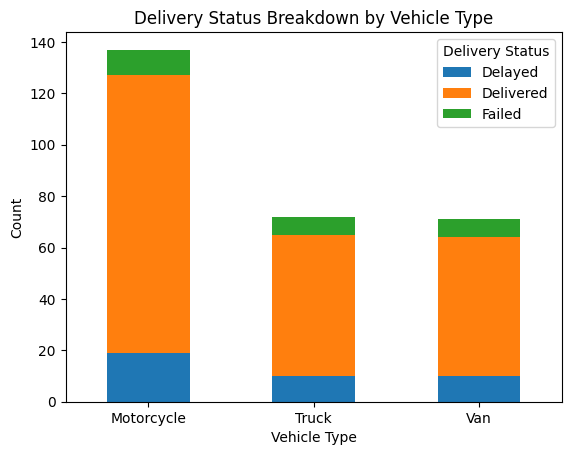

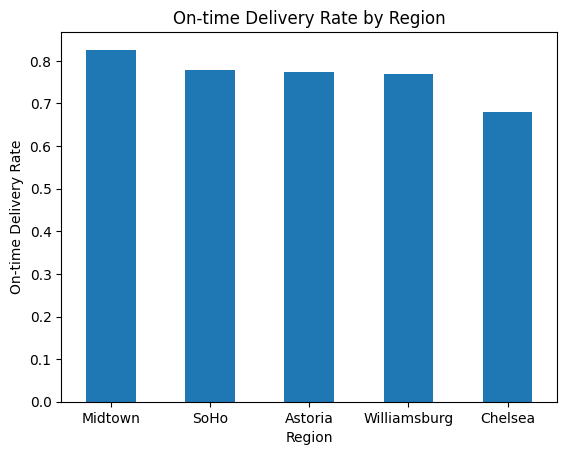

In [145]:
# Visualization
import matplotlib.pyplot as plt
# import seaborn as sns

# Chart 1: Delivery status breakdown by vehicle type (grouped or stacked bar chart)
data = pd.merge(deliveries_df, drivers_df, on='driver_id', how='left')
data.groupby(['vehicle_type', 'delivery_status']).size().unstack().plot(kind='bar', stacked=True, rot=0)
plt.title('Delivery Status Breakdown by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Count')
plt.legend(title='Delivery Status')
plt.show()
# plt.figure(figsize=(10, 6))
# plt.title('Chart 1')
# plt.show()

# Chart 2: On-time delivery rate by region (bar chart)
data = pd.merge(deliveries_df, drivers_df, on='driver_id', how='left')
(data['delivery_status'] == 'Delivered').groupby(data['region']).mean().sort_values(ascending=False).plot(kind='bar', rot=0)
plt.title('On-time Delivery Rate by Region')
plt.xlabel('Region')
plt.ylabel('On-time Delivery Rate')
plt.show()
# plt.figure(figsize=(10, 6))
# plt.title('Chart 2')
# plt.show()


---
# 💼 Business Insights
**What did I discover?**

- Motorcycle has more Delayed (**19**) and Failed (**10**) deliveries than Truck and Van (**10** and **7** each).
  (오토바이가 트럭·밴보다 Delayed 19, Failed 10으로 더 많음. 트럭·밴은 각각 10, 7)
- Average weight is **3.03 kg** (Motorcycle), **15.73 kg** (Van), and **81.47 kg** (Truck).
  (평균 무게는 오토바이 3.03kg, 밴 15.73kg, 트럭 81.47kg)
- The overall on-time rate is **0.775**. Midtown (**0.826**) is above it and Chelsea (**0.680**) is below it.
  (전체 정시배송률 0.775. Midtown 0.826은 높고 Chelsea 0.680은 낮음)
  

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Do not blame Motorcycle for the higher Delayed and Failed counts yet. Counts are raw numbers, so check them against how many deliveries each vehicle type made.
   (오토바이 탓으로 단정하지 말 것. 건수는 원본 숫자라서 차종별 전체 배송 수와 같이 봐야 함)
2. Look into Chelsea (**0.680**) first, since it is the lowest region.
   (가장 낮은 Chelsea 0.680부터 원인을 확인)
3. Check each region's number of deliveries before acting. A rate from a small group can swing easily.
   (조치 전에 지역별 배송 건수를 확인. 건수가 적은 곳의 비율은 쉽게 흔들림)
   

---
# ❌ Mistakes
**What mistakes did I make today?**

- `if x` does not catch a missing value, because a missing value is `NaN` and `NaN` counts as True. My `lambda` failed on it.
  (결측은 NaN이고 NaN은 True로 취급돼서 `if x`로 못 거름. lambda가 거기서 에러)
- Chart 2 had only one bar series, so `stacked=True` and the legend were not needed.
  (차트 2는 막대 시리즈가 하나라 stacked와 범례가 필요 없었음)
- The x labels were vertical until I added `rot=0`.
  (rot=0을 넣기 전에는 x축 글자가 세로)
  

---
# ✅ What I Learned
**Today's biggest lesson**

- `pd.to_numeric(series.str.replace('kg', '').str.strip(), errors='coerce')` cleans mixed text into numbers and keeps missing values as `NaN`.
  (str.replace와 str.strip 뒤 to_numeric(errors='coerce')로 섞인 텍스트를 숫자로 만들고 결측은 NaN으로 유지)
- `(col == 'Delivered').groupby(other).mean()` gives a rate per group, because True counts as 1 and False as 0.
  (True는 1, False는 0이라 불리언의 평균이 그룹별 비율)
- `.sort_values()` sorts a pandas result (SQL's `ORDER BY`), and `rot=0` keeps the x labels horizontal.
  (sort_values는 pandas에서 정렬(SQL의 ORDER BY), rot=0은 x축 글자를 가로로)
  

---
# 🧠 Reflection

**What was difficult?**
Cleaning `weight_kg` with missing values.
(결측이 섞인 weight_kg 정제)

**Why?**
Missing values are `NaN`, so a string method or an `if` check behaves differently from normal text.
(결측은 NaN이라 문자열 메서드나 if 검사가 일반 텍스트와 다르게 동작)

**How did I solve it?**
Used the `.str` methods and `pd.to_numeric(errors='coerce')` instead of `lambda`.
(lambda 대신 .str 메서드와 to_numeric(errors='coerce')를 사용)

**What would I do differently next time?**
Check for missing values before writing a cleaning function. Check whether a chart needs a legend or stacking at all.
(정제 함수 쓰기 전에 결측부터 확인. 차트에 범례나 누적이 필요한지부터 확인)



---
# ⭐ Self Evaluation

**Understanding**
★★★★★★★☆☆☆
(SQL과 pandas를 같이 쓰는 흐름은 이해. 결측 처리는 도움 필요)

**Confidence**
★★★★★★☆☆☆☆

**Difficulty**
★★★★★☆☆☆☆☆
(무게 정제가 제일 어려웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 13 — capstone 1: customer segmentation
  (캡스톤 1: 고객 세분화)
  